In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import *
from qiskit_aer import AerSimulator
import numpy as np
from scipy.optimize import curve_fit

from qiskit_ibm_runtime import QiskitRuntimeService

import matplotlib.pyplot as plt

In [4]:
QiskitRuntimeService.delete_account(name='ibm_quantum_platform')

False

Backend Activate code

In [5]:
QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="I5aqjSTGPQk-2tnBsYN4GTNZQyoV7AFgle-LuIWExFX8")

AccountAlreadyExistsError: 'Named account (default-ibm-quantum-platform) already exists. Set overwrite=True to overwrite.'

In [2]:
service = QiskitRuntimeService()
# Real Backend
backend_qc = service.least_busy(operational=True, simulator=False)
# Fake Backend(Noisy Simulator)_Try Other FakeBackend!
backend_sim = FakeArmonkV2()
# backend_sim = AerSimulator() # Ideal Simulator
# Choose Backend
backend = backend_sim

qiskit_runtime_service.__init__:WARNING:2025-12-17 12:50:33,925: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium), the available account instances are: 0_UNIST_UNIST -eu, 0_UNIST_UNIST. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-12-17 12:50:34,830: Loading instance: 0_UNIST_UNIST -eu, plan: premium
qiskit_runtime_service.backends:WARNING:2025-12-17 12:50:36,758: Loading instance: 0_UNIST_UNIST, plan: premium
qiskit_runtime_service.backends:WARNING:2025-12-17 12:50:41,292: Using instance: 0_UNIST_UNIST -eu, plan: premium


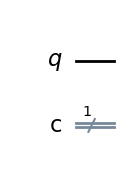

In [3]:
# 1 Qubit and 1 classical bit
qc = QuantumCircuit(1,1)

# Draw QuantumCircuit
qc.draw(output='mpl')


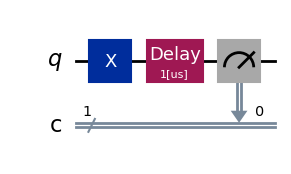

In [4]:
# Set time delay 
delay=1
qc.x(0)
qc.delay(delay,unit = 'us' ) # give - us delay
qc.measure(0,0)
# Draw QuantumCircuit
qc.draw(output='mpl')


In [7]:
#To pack gates right before measurement (To apply accurate delay)
transpiled_circ=transpile(qc, backend, scheduling_method= 'alap')
# Build Sampler
sampler = Sampler(backend)
# Run Sampler
shot_num = 2048
job = sampler.run([transpiled_circ], shots = shot_num)
# Get result from your job
result = job.result()
# get counts for Sampler jobs
count = result[0].data.c.get_counts()
# Show your work!
print(f" > Counts: {count}")

 > Counts: {'1': 1983, '0': 65}


In [9]:
# Set Parameters
t = [] # Time List
prob1 = [] # Excited State Probability List
shot_num = 1000 # Shot Number
t_range = 500 # Set Maximum Time Range (us)

# To perform repetitive tasks, Session is important
with Session(backend=backend) as session:    
    sampler = Sampler(mode=session)    
    for delay in range(t_range+1):        
        qc=QuantumCircuit(1,1)   
        qc.x(0)        
        qc.delay(delay,unit = 'us' )        
        qc.measure(0,0)                
        transpiled_circ=transpile(qc, backend, scheduling_method= 'alap')        
        job = sampler.run([transpiled_circ], shots = shot_num)        
        result = job.result()        
        count = result[0].data.c.get_counts()                
        t.append(delay)        
        prob1.append(count['1']/shot_num)            


Text(0.5, 1.0, 'T1 delay (us) for fake_armonk')

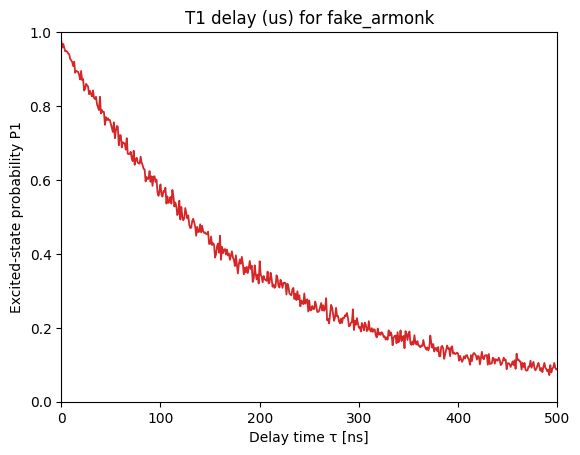

In [14]:
# 간단하게plot 하고싶으면plt.plot(t,prob1) 만 작성해도 됩니다.
import matplotlib.pyplot as plt
#plt.plot(t,prob1) 
plt.plot(t, prob1, color='tab:Red', linestyle='-', marker='',lw=1.3)
#plt.gcf().set_facecolor('#bdc3c7’)
plt.xlim(0,t_range)
plt.ylim(0, 1)
plt.xlabel('Delay time τ [ns]')
plt.ylabel('Excited-state probability P1')
plt.title('T1 delay (us) for '+ str(backend.name))